<h1 style="font-size:48px; text-align:center;">Umbrella Mechanism Analysis</h1>

<figure style="text-align:center;">
  <img src="../figures/umbrella_labels.png" width="500">
  <figcaption style="font-size:16px; color:gray;">Labels of the umbrella bars</figcaption>
</figure>



<div style="max-width: 700px; margin: 0 auto;text-align: justify;">

For our model, we selected a beach umbrella with a diameter of 3.5 m. The umbrella has a double-folding mechanism, allowing it to remain compact despite its large span. Because of its size, an 8-rib frame is the most common configuration. Therefore, the calculated outcomes should be multiplied by 8.

The 2.5th-percentile female overhead reach is 182 cm (71.6 in) ([source](https://ftp.idu.ac.id/wp-content/uploads/ebook/ip/BUKU%20ERGONOMI/BUKU%20INGGRIS/An%20Intruduction%20to%20Human%20Factors%20Engineering.pdf)). The maximum gliding height should remain around this value. We consider that this movement can be made in 3 to 5 seconds, which is a good estimation of a real manual extension time. 

Studies show that operation forces lasting 4 seconds should be kept below 4.3 kg in overhead positions for women ([source](https://journals.sagepub.com/doi/abs/10.3233/OER-2005-5301))

When fully extended, the umbrella forms an angle of approximately $20^\circ$ with the horizontal (angle $\theta4$), producing an aesthetically pleasing dome shape.

Bars where chosen as symmetric as possible, for a compacter fold in height.

</div> 


<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Mobility of the mechanism </h3>
The Chebychev–Grübler–Kutzbach formula for mobility in a plane gives: 

$$M = {\color{red}3}(n − 1) − {\color{blue}2}f_1 − f_2$$

With:

$n = 7$

$f_1 = 8 $

$f_2 = 1 $

resulting in $M = 1$


</div> 

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Kinematics of the mechanism </h3>
Main libraries are being imported, lengths are being attributed together with initialization and definition of the input movement. Afterwards we compose the closure equations that are specific to our mechanism. For all the relevant angles, position, velocity and acceleration has to be computed.
</div>

In [1]:
# import necessary libraries for computing
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
<h4>Initialitation and definition</h4>
As mentioned previously, we would like a dome angle of around 20 degrees when the umbrella is fully deployed. Length r3a is computed as such that this can be realised and at the same time a perpendicular lever can be created. We assume the upward motion of the glider is realised in 3 seconds and follows a minimal jerk, quintic trajectory. 
</div>

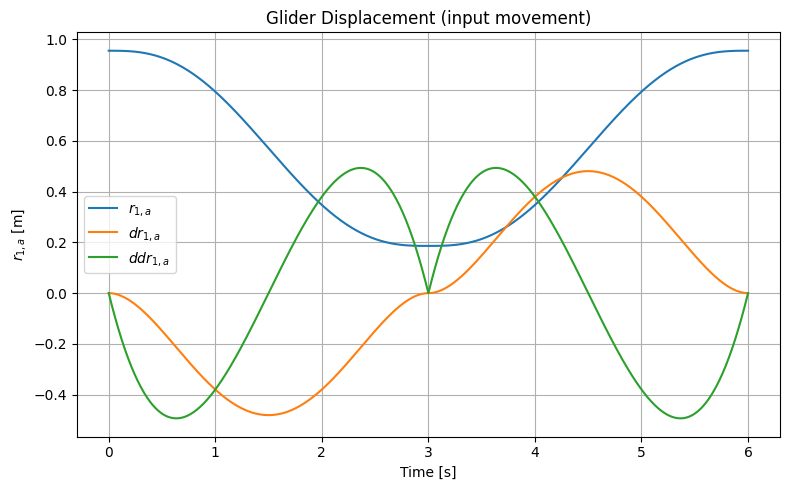

In [2]:
# Data initialization (all data is in SI units)
# kinematic parameters (bar lengths)

dome_angle = 20 # degrees

# r4a + r4b + r7b + r8b = 1.75m (3.5m diameter of dome) 
# bar lengths divided equally
r3b = 0.125 #m 
r4a = 0.5 #m 
r3a = r4a*np.cos(np.radians(dome_angle))-r3b #m  compute to get perpendicular lever when fully deployed under dome angle

r4b = 0.5 #m 

r5a = 0.375 #m 
r5b = 0.125 #m
r6 = 0.5 #m

r7a = 0.125 #m
r7b = 0.375 #m

r8a = 0.125 #m
r8b = 0.375 #m

r1 = 2 #m sun umbrella heigth such that maximum gliding heighth is around 1.82m (r1 - r4a*sin(dome_angle) approx 1.82m)

# parameters of actuation and simulation

# initial values for position analysis: starting with all bars vertical
phi4_init = 3*np.pi/2   
phi3_init = np.pi/2
phi5_init = 3*np.pi/2  
phi7_init = np.pi/2
phi6_init = np.pi/2
phi8_init = 3*np.pi/2
phi_init=[phi3_init,phi4_init,phi5_init,phi7_init,phi6_init,phi8_init]


t_begin =  0     # start time of simulation
t_end   = 6     # end time of simulation
Ts      =  0.01  # time step of simulation
t = np.arange(t_begin, t_end + Ts, Ts) # time vector

#possibility to implement with a rotating umbrella too
phi1 = 3*np.pi/2 +0*t #rad cst for the moment
dphi1=0*t
ddphi1=0*t

# initialization of driver via minimum jerk trajectory for smooth motion
x0 = r3a+r3b+r4a - 0.015  # start position of driver (glider) slightly below the initial position to ensure it starts moving upwards
dx = x0 - r4a*np.sin(np.radians(dome_angle))-0.015 # total distance to be covered by driver to reach the maximum gliding height (slightly below to ensure it reaches the maximum height)
T = t_end - t_begin # total time of motion

# minimum jerk trajectory for out and back motion of driver (glider) with T the one way time of motion (time to reach the maximum gliding height)
def quintic_out_and_back(t, x0, dx, T):

    x = np.zeros_like(t, dtype=float)
    v = np.zeros_like(t, dtype=float)
    a = np.zeros_like(t, dtype=float)

    mask1 = (t >= 0) & (t <= T)
    tau1 = t[mask1] / T

    x[mask1] = x0 - dx*(10*tau1**3 - 15*tau1**4 + 6*tau1**5)
    v[mask1] = -(dx/T)*(30*tau1**2 - 60*tau1**3 + 30*tau1**4)
    a[mask1] = -(dx/T**2)*(60*tau1 - 180*tau1**2 + 120*tau1**3)

    mask2 = (t > T) & (t <= 2*T)
    tau2 = (t[mask2] - T) / T

    x[mask2] = (x0 - dx) + dx*(10*tau2**3 - 15*tau2**4 + 6*tau2**5)
    v[mask2] = (dx/T)*(30*tau2**2 - 60*tau2**3 + 30*tau2**4)
    a[mask2] = (dx/T**2)*(60*tau2 - 180*tau2**2 + 120*tau2**3)

    x[t < 0] = x0
    x[t > 2*T] = x0

    return x, v, a

# linear position, velocity and acceleration:
r1a, dr1a, ddr1a = quintic_out_and_back(t, x0, dx, T/2) 
r1b=r1-r1a
dr1b=-dr1a
ddr1b=-ddr1a

# 1. Glider displacement
figsize = (8, 5)
plt.figure(figsize=figsize)
plt.plot(t, r1a, label=r'$r_{1,a}$')
plt.plot(t, dr1a, label=r'$dr_{1,a}$')
plt.plot(t, ddr1a, label=r'$ddr_{1,a}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$r_{1,a}$ [m]')
plt.title('Glider Displacement (input movement)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
<h4>Loop closure equations</h4>
As example of a loop closure equation, we take our first loop:

$\vec{r1a} + \vec{r3a} + \vec{r3b} = \vec{r4a}$

In X and Y <b>coordinates</b> this gives for the first loop:

- X:  $r_{1a} \cos(\phi_{1}) + (r_{3a}+r_{3b}) \cos(\phi_{3}) - r_{4a} \cos(\phi_{4})$ .

- Y:  $r_{1a} \sin(\phi_{1}) + (r_{3a}+r_{3b}) \sin(\phi_{3}) - r_{4a} \sin(\phi_{4})$ .

The other loops are computed similarly.
</div>

In [4]:
# Define loop closure equation1 (solve for phi3 and phi4) => loop r1a, r3a, r3b, r4a
def loop_closure_eqs1(phi_init, r1a, r4a, r3a, r3b, phi1):
    phi3 = phi_init[0]
    phi4 = phi_init[1]

    # Loop closure equations 1 
    F1 = r1a*np.cos(phi1)+(r3a+r3b)*np.cos(phi3)-r4a*np.cos(phi4) #X
    F2 = r1a*np.sin(phi1)+(r3b+r3a)*np.sin(phi3)-r4a*np.sin(phi4) #Y

    return [F1, F2]

In [5]:
# Define loop closure equation2 (solve for phi5, phi7) => loop r5a, r7a, r5b, r3b and r4b
def loop_closure_eqs2(phi_init, phi_oplossing, r5a, r7a, r5b, r3b,r4b):
    phi5 = phi_init[0]
    phi7 = phi_init[1]

    phi3 = phi_oplossing[0]
    phi4 = phi_oplossing[1]
    
    # Loop closure equations 2
    F3 = (r5a+r5b)*np.cos(phi5)+r7a *np.cos(phi7)-r3b*np.cos(phi3)-r4b*np.cos(phi4)
    F4 = (r5a+r5b)*np.sin(phi5)+r7a*np.sin(phi7)-r3b*np.sin(phi3)-r4b*np.sin(phi4)

    return [F3, F4]

In [6]:
# Define loop closure equation3 (solve for phi6, phi8) => loop r6, r7a, r5b, r7b, r8a
def loop_closure_eqs3(phi_init, phi_oplossing, r6, r7a, r5b, r7b, r8a):
    phi6 = phi_init[0]
    phi8 = phi_init[1]
    phi5 = phi_oplossing[2]
    phi7 = phi_oplossing[3]

    # Loop closure equations 3
    F5 = r5b*np.cos(phi5)+(r7a+r7b)*np.cos(phi7)-r6*np.cos(phi6)-r8a*np.cos(phi8)
    F6 = r5b*np.sin(phi5)+(r7a+r7b)*np.sin(phi7)-r6*np.sin(phi6)-r8a*np.sin(phi8)

    return [F5, F6]

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
<h4>Compute kinematics</h4>
Once we have the three loop closure equations that define our mechanism for solving the angular positions, we can also solve the angular velocities and accelerations by differentiating these loops. The angular positions are not unknown anymore so the unknown velocities and accelerations form linear equations. We do this iteratively for each timestemp. After each timestemp the initial guesses have to be updated.
</div>

In [7]:
# solve position, velocity and acceleration of the 8-bar mechanism for the given input parameters and time vector
def kinematics_8bar(r1a, r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a, phi1, dphi1,ddphi1, dr1a, ddr1a, phi_init, t):
    global phi3, phi4, phi5, phi6, phi7, phi8
    global dphi3, dphi4, dphi5, dphi6, dphi7, dphi8
    global ddphi3, ddphi4, ddphi5, ddphi6, ddphi7, ddphi8
    global cond1, cond2, cond3
    # position arrays
    phi3   = np.zeros_like(t)
    phi4   = np.zeros_like(t)
    phi5   = np.zeros_like(t)
    phi6   = np.zeros_like(t)
    phi7   = np.zeros_like(t)
    phi8   = np.zeros_like(t)

    # velocity arrays (first derivatives)
    dphi3  = np.zeros_like(t)
    dphi4  = np.zeros_like(t)
    dphi5  = np.zeros_like(t)
    dphi6  = np.zeros_like(t)
    dphi7  = np.zeros_like(t)
    dphi8  = np.zeros_like(t)

    # Acceleration-arrays (second derivatives)
    ddphi3 = np.zeros_like(t)
    ddphi4 = np.zeros_like(t)
    ddphi5 = np.zeros_like(t)
    ddphi6 = np.zeros_like(t)
    ddphi7 = np.zeros_like(t)
    ddphi8 = np.zeros_like(t)

    # condition numbers of the jacobian matrices for velocity and acceleration analysis
    cond1   = np.zeros_like(t)
    cond2   = np.zeros_like(t)
    cond3   = np.zeros_like(t)

    optim_options = {"full_output":True}  # options for fsolve
    phi_oplossing=[0,0,0,0,0,0]
    for k, time in enumerate(t):

        # Position Analysis loop 1
        x1, _, ier1, message1  = fsolve(lambda x1: loop_closure_eqs1(x1, r1a[k], r4a, r3a, r3b, phi1[k]), phi_init[0:2], **optim_options)
        if ier1 != 1:
            print("The fsolve1 exit flag was not 1, probably no convergence!")
            print(message1)

        phi3[k] = x1[0]
        phi4[k] = x1[1]
        phi_oplossing[0]=phi3[k]
        phi_oplossing[1]=phi4[k]

        # Position Analysis loop 2
        x2, _, ier2, message2  = fsolve(lambda x2: loop_closure_eqs2(x2, phi_oplossing, r5a, r7a, r5b, r3b,r4b), phi_init[2:4], **optim_options)
        if ier2 != 1:
            print("The fsolve2 exit flag was not 1, probably no convergence!")
            print(message2)
        phi5[k] = x2[0]
        phi7[k] = x2[1]
        phi_oplossing[2]=phi5[k]
        phi_oplossing[3]=phi7[k]
        
        # Position Analysis loop 3
        x3, _, ier3, message3  = fsolve(lambda x3: loop_closure_eqs3(x3, phi_oplossing, r6, r7a, r5b, r7b, r8a), phi_init[4:6], **optim_options)
        if ier3 != 1:
            print("The fsolve3 exit flag was not 1, probably no convergence!")
            print(message3)
        phi6[k] = x3[0]
        phi8[k] = x3[1]
        phi_oplossing[4]=phi6[k]
        phi_oplossing[5]=phi8[k]

        # Velocity Analysis loop 1
        A1 = np.array([[(r3a+r3b)*np.sin(phi3[k]),-r4a*np.sin(phi4[k]) ],
                      [(r3a+r3b) * np.cos(phi3[k]), -r4a * np.cos(phi4[k])]])
        B1 = np.array([np.cos(phi1[k])*dr1a[k]+r1a[k]*np.sin(phi1[k])*dphi1[k],
                      -np.sin(phi1[k])*dr1a[k]]-r1a[k]*np.cos(phi1[k])*dphi1[k])

        x1 = np.linalg.solve(A1, B1)
        dphi3[k] = x1[0]
        dphi4[k] = x1[1]
        cond1[k]  = np.linalg.cond(A1)

        # Acceleration Analysis loop 1
        B1 = np.array([-(r3a+r3b)*np.cos(phi3[k])*(dphi3[k])**2+ddr1a[k]*np.cos(phi1[k])+r4a*np.cos(phi4[k])*(dphi4[k])**2-2*dr1a[k]*np.sin(phi1[k])*dphi1[k]-r1a[k]*np.cos(phi1[k])*(dphi1[k])**2-r1a[k]*np.sin(phi1[k])*ddphi1[k],
                      -r4a*np.sin(phi4[k])*(dphi4[k])**2-ddr1a[k]*np.sin(phi1[k])-2*dr1a[k]*np.cos(phi1[k])*dphi1[k]+r1a[k]*np.sin(phi1[k])*(dphi1[k])**2-r1a[k]*np.cos(phi1[k])*ddphi1[k]+(r3a+r3b)*np.sin(phi3[k])*(dphi3[k])**2])

        x1 = np.linalg.solve(A1, B1)
        ddphi3[k] = x1[0]
        ddphi4[k] = x1[1]
        
        # Velocity Analysis loop 2
        A2 = np.array([[(r5a+r5b)*np.sin(phi5[k]), r7a*np.sin(phi7[k])],
                      [(r5a+r5b)*np.cos(phi5[k]), r7a*np.cos(phi7[k])]])
        B2 = np.array([r3b*np.sin(phi3[k])*dphi3[k]+r4b*np.sin(phi4[k])*dphi4[k],
                      r3b*np.cos(phi3[k])*dphi3[k]+r4b*np.cos(phi4[k])*dphi4[k]])

        x = np.linalg.solve(A2, B2)
        dphi5[k] = x[0]
        dphi7[k] = x[1]
        cond2[k]  = np.linalg.cond(A2)

        # Acceleration Analysis loop 2
        B2 = np.array([r3b*np.sin(phi3[k])*ddphi3[k]+r3b*np.cos(phi3[k])*(dphi3[k])**2+r4b*np.cos(phi4[k])*(dphi4[k])**2+r4b*np.sin(phi4[k])*ddphi4[k]-(r5b+r5a)*np.cos(phi5[k])*(dphi5[k])**2-r7a*np.cos(phi7[k])*(dphi7[k])**2,
                      (r5a+r5b)*np.sin(phi5[k])*(dphi5[k])**2+r7a*np.sin(phi7[k])*(dphi7[k])**2-r3b*np.sin(phi3[k])*(dphi3[k])**2+r3b*np.cos(phi3[k])*ddphi3[k]-r4b*np.sin(phi4[k])*(dphi4[k])**2+r4b*np.cos(phi4[k])*ddphi4[k]])

        x = np.linalg.solve(A2, B2)
        ddphi5[k] = x[0]
        ddphi7[k] = x[1]
        
        # Velocity Analysis loop 3
        A3 = np.array([[(r6)*np.sin(phi6[k]), (r8a)*np.sin(phi8[k])],
                      [(r6)*np.cos(phi6[k]), (r8a)*np.cos(phi8[k])]])
        B3 = np.array([r5b*np.sin(phi5[k])*dphi5[k]+(r7a+r7b)*np.sin(phi7[k])*dphi7[k],
                      r5b*np.cos(phi5[k])*dphi5[k]+(r7a+r7b)*np.cos(phi7[k])*dphi7[k]])

        x = np.linalg.solve(A3, B3)
        dphi6[k] = x[0]
        dphi8[k] = x[1]
        cond3[k]  = np.linalg.cond(A3)

        # Acceleration Analysis loop 3
        B3 = np.array([r5b*np.cos(phi5[k])*dphi5[k]**2+r5b*np.sin(phi5[k])*ddphi5[k]+(r7a+r7b)*np.cos(phi7[k])*dphi7[k]**2+(r7a+r7b)*np.sin(phi7[k])*ddphi7[k]-r6*np.cos(phi6[k])*dphi6[k]**2-r8a*np.cos(phi8[k])*dphi8[k]**2,
                       r5b*np.cos(phi5[k])*ddphi5[k]-r5b*np.sin(phi5[k])*dphi5[k]**2+(r7a+r7b)*np.cos(phi7[k])*ddphi7[k]-(r7a+r7b)*np.sin(phi7[k])*dphi7[k]**2+r6*np.sin(phi6[k])*dphi6[k]**2+r8a*np.sin(phi8[k])*dphi8[k]**2
        ])
        x = np.linalg.solve(A3, B3)
        ddphi6[k] = x[0]
        ddphi8[k] = x[1]

        # Initialization of the next iteration step
        phi3_init = phi3[k] + (t[1] - t[0]) * dphi3[k]
        phi4_init = phi4[k] + (t[1] - t[0]) * dphi4[k]
        phi_init[0]=phi3_init
        phi_init[1]=phi4_init
        phi5_init = phi5[k] + (t[1] - t[0]) * dphi5[k]
        phi7_init = phi7[k] + (t[1] - t[0]) * dphi7[k]
        phi_init[2]=phi5_init
        phi_init[3]=phi7_init
        phi6_init = phi6[k] + (t[1] - t[0]) * dphi6[k]
        phi8_init = phi8[k] + (t[1] - t[0]) * dphi8[k]
        phi_init[4]=phi6_init
        phi_init[5]=phi8_init

        

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
<h4>Animation of the mechanism </h4>
Now that our kinematic solver function has been defined we can also animate our mechanism.
</div>

In [8]:
# Animation of mechanism motion
global fig, ax, x_left, x_right, y_bottom, y_top, P, S, index_vec
# compute width and height of drawing canvas:
x_left   = -0.1
y_bottom = -0.5
x_right  = r4a+r4b+r7b+r8b 
y_top    = 3

# Don't show figure until drawn explicitly:
plt.ioff()
# Initialize the figure
fig, ax = plt.subplots()

# Define the function to update the plot for each frame:
t_size = len(t)
# fraction of simulated frames in the animation:
frames = t_size/10

# Define point C as ground link:
C = np.array([0,0])

# time between frames
delta = int(np.floor(t_size / frames))
# index vector for frames        
index_vec = np.arange(0, t_size, delta)

# calculation and visualisation of the kinematics:
kinematics_8bar(r1a, r3a, r3b, r4a, r4b, r5a, r5b, r6, r7a, r7b, r8a, phi1, dphi1, ddphi1, dr1a, ddr1a, phi_init, t)

# next step in the animation:
def update(frame):
    ax.cla()  # Clear the current axes
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates using rotation matrix
    A = C + rotate_vector(np.array([r1a[frame], 0]), phi1[frame])
    E = C + rotate_vector(np.array([r4a, 0]), phi4[frame])
    D = A + rotate_vector(np.array([r3a, 0]), phi3[frame])
    F = D + rotate_vector(np.array([r5a, 0]), phi5[frame])
    G = F + rotate_vector(np.array([r5b, 0]), phi5[frame])
    H = G + rotate_vector(np.array([r7a, 0]), phi7[frame])
    J = H + rotate_vector(np.array([r7b, 0]), phi7[frame])
    I = F + rotate_vector(np.array([r6, 0]), phi6[frame])
    K = J + rotate_vector(np.array([r8b, 0]), phi8[frame])
    L = A + rotate_vector(np.array([r1b[frame], 0]), phi1[frame])
    
    loop1 = np.array([C, E,D, A])
    loop2 = np.array([D, E, H,G])
    loop3 = np.array([F, I, J, G])
    loop4 = np.array([I, J, K])
    loop5 = np.array([D, F, G])
    loop6 = np.array([C, A, L])

    ax.plot(loop1[:, 0], loop1[:, 1], '-o')
    ax.plot(loop2[:, 0], loop2[:, 1], '-o')
    ax.plot(loop3[:, 0], loop3[:, 1], '-o')
    ax.plot(loop4[:, 0], loop4[:, 1], '-o')
    ax.plot(loop5[:, 0], loop5[:, 1], '-o')
    ax.plot(loop6[:, 0], loop6[:, 1], '-o')

    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)


In [9]:
# display mechanism animation:
from IPython.display import HTML
HTML(ani.to_jshtml())


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
<h4> Angular velocities and accelerations </h4>
Underneath we are plotting the kinematics of the six main angles. If bar lengths are chosen symmetrically, 

$\phi_{3}$, $\phi_{6}$ and $\phi_{7}$ are following the same velocity and accelration profiles
</div>

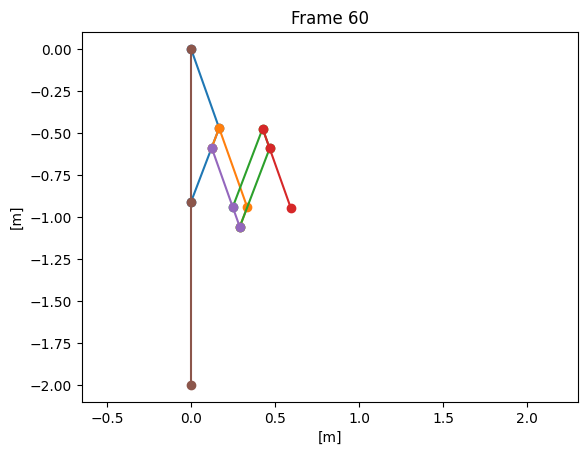

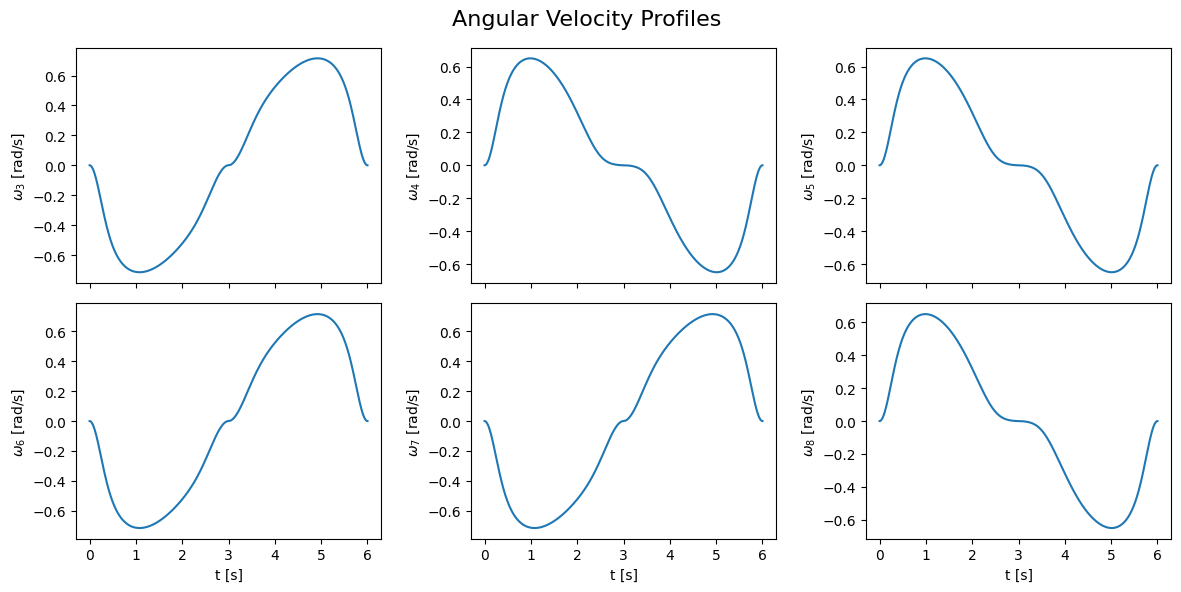

In [10]:
# plot velocity profiles of phi3, phi4, phi5, phi6, phi7 and phi8:

fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
fig.suptitle('Angular Velocity Profiles', fontsize=16)
axs[0, 0].plot(t, dphi3)
axs[0, 0].set_ylabel(r'$\omega_3$ [rad/s]')

axs[0, 1].plot(t, dphi4)
axs[0, 1].set_ylabel(r'$\omega_4$ [rad/s]')

axs[0, 2].plot(t, dphi5)
axs[0, 2].set_ylabel(r'$\omega_5$ [rad/s]')

axs[1, 0].plot(t, dphi6)
axs[1, 0].set_ylabel(r'$\omega_6$ [rad/s]')
axs[1, 0].set_xlabel('t [s]')

axs[1, 1].plot(t, dphi7)
axs[1, 1].set_ylabel(r'$\omega_7$ [rad/s]')
axs[1, 1].set_xlabel('t [s]')

axs[1, 2].plot(t, dphi8)
axs[1, 2].set_ylabel(r'$\omega_8$ [rad/s]')
axs[1, 2].set_xlabel('t [s]')

plt.tight_layout()
plt.show()

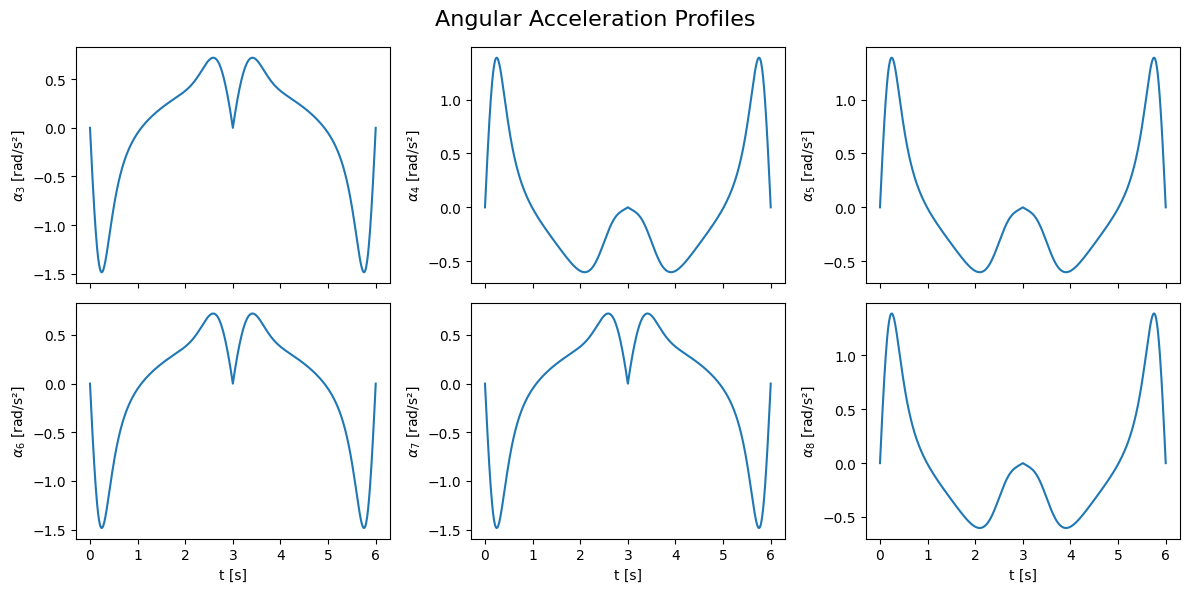

In [11]:
# plot acceleration profiles of phi3, phi4, phi5, phi6, phi7 and phi8:

fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
fig.suptitle('Angular Acceleration Profiles', fontsize=16)
axs[0, 0].plot(t, ddphi3)
axs[0, 0].set_ylabel(r'$\alpha_3$ [rad/s²]')

axs[0, 1].plot(t, ddphi4)
axs[0, 1].set_ylabel(r'$\alpha_4$ [rad/s²]')

axs[0, 2].plot(t, ddphi5)
axs[0, 2].set_ylabel(r'$\alpha_5$ [rad/s²]')

axs[1, 0].plot(t, ddphi6)
axs[1, 0].set_ylabel(r'$\alpha_6$ [rad/s²]')
axs[1, 0].set_xlabel('t [s]')

axs[1, 1].plot(t, ddphi7)
axs[1, 1].set_ylabel(r'$\alpha_7$ [rad/s²]')
axs[1, 1].set_xlabel('t [s]')

axs[1, 2].plot(t, ddphi8)
axs[1, 2].set_ylabel(r'$\alpha_8$ [rad/s²]')
axs[1, 2].set_xlabel('t [s]')

plt.tight_layout()
plt.show()

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Dynamics of the mechanism </h3>
In this section the forces acting on/in the mechanism will be computed. Functions are being created that will serve later on. Also a bar class is being created that has all properties necessary for dynamic analysis and force computations. This approach will be very useful to get compacter, more understandable code and especially for computing the operator force of the glider using the change in kinetic energy.
<h4>Forces of the mechanism without friction</h4>
In underneath code wa assume all bars are manufactured in aluminium with a diameter of 1 cm and the COG lying in the middle of the bar. All these variables can be adapted as desired. Also the gravity constant can be modified. For now the friction of the glider is neglected.

</div>

In [12]:
# Computing the forces on the mechanism when realising this movement
# Calculate next joint velocity based on current joint velocity, position and angular velocity
def next_joint_vel(vA, r,phi, dphi):
    vx = vA[0] - r*np.sin(phi)*dphi
    vy = vA[1] + r*np.cos(phi)*dphi
    return np.array([vx, vy])

# Calculate next joint aceleration based on current joint acceleration, velocity and position
def next_joint_acc(aA, r, phi, dphi, ddphi):
    ax = aA[0] - r*np.cos(phi)*dphi**2 - r*np.sin(phi)*ddphi
    ay = aA[1] - r*np.sin(phi)*dphi**2 + r*np.cos(phi)*ddphi
    return np.array([ax, ay])
# Calculate the velocity or acceleration of the CoG based on the velocity or acceleration of the beginning and end of the link and the position of the CoG on the link
def cog_kinematics(valA, valB, Cog_parameter):
    v_mid = valA * (1 - Cog_parameter) + valB * Cog_parameter
    return v_mid
# Define a class for the bars of the mechanism, to compute mass and inertia based on the geometry and material properties, and to compute the forces on the bars based on the kinematics of the mechanism
class BarLink:
    def __init__(self, density, diameter, length, vBegin, vEnd, aBegin, aEnd, Cog_parameter, intern_joint_position=None, angular_velocity=None, angular_acceleration=None):
        self.density = density    # kg/m^3
        self.diameter = diameter  # meters
        self.length = length      # meters
        self.angular_velocity = angular_velocity  # rad/s (optional), used when considering the moment of inertia and rotational dynamics
        self.angular_acceleration = angular_acceleration  # rad/s^2 (optional), used when considering the moment of inertia and rotational dynamics
        self.Cog_parameter = Cog_parameter  # CoG position as a fraction of the link length
        self.intern_joint_position = intern_joint_position  # Internal joint position as a distance from the beginning of the link

        # kinematics of the CoM (considering CoM at the middle of the link)
        self.velocity = cog_kinematics(vBegin, vEnd, self.Cog_parameter)
        self.acceleration = cog_kinematics(aBegin, aEnd, self.Cog_parameter)

    @property
    def cross_sectional_area(self):
        """Calculates area: A = π * r²"""
        radius = self.diameter / 2
        return np.pi * (radius**2)

    @property
    def volume(self):
        """Calculates volume: V = Area * Length"""
        return self.cross_sectional_area * self.length

    @property
    def mass(self):
        """Calculates mass: m = Density * Volume"""
        return self.density * self.volume
    @property
    def distance_Cog_intern_joint(self):
        """Calculates distance from CoG to internal joint, if positive => positive moment (on the right of the CoG)"""
        return self.intern_joint_position - self.Cog_parameter * self.length
    
    def distance_Cog_joint(self, joint_number):
        """Calculates distance from CoG to joint, if positive => positive moment (on the right of the CoG)"""
        if joint_number == 1:
            return self.Cog_parameter * self.length
        elif joint_number == 2:
            return self.length - self.Cog_parameter * self.length
    @property
    def inertia(self):
        """Calculates moment of inertia about the CoG for a rod rotating about its center: I = (1/12) * m * L²"""
        return (1/12) * self.mass * self.length**2

N = len(phi4) #length of calculated timepoints

# Define kinematics of fixed point C 
vC = np.zeros((2,N))
aC = np.zeros((2,N))

# Calculate the kinematics of each joint using C and in a well defined sequence
vA = np.array([np.zeros(N), -dr1a]) # possitve velocity of A is defined opposite to the r1a extension
aA = np.array([np.zeros(N), -ddr1a])

vE = next_joint_vel(vC, r4a, phi4, dphi4)
aE = next_joint_acc(aC, r4a, phi4, dphi4, ddphi4)

vH = next_joint_vel(vC, r4a+r4b, phi4, dphi4)
aH = next_joint_acc(aC, r4a+r4b, phi4, dphi4, ddphi4)

vD = next_joint_vel(vA, r3a, phi3, dphi3)
aD = next_joint_acc(aA, r3a, phi3, dphi3, ddphi3)

vF = next_joint_vel(vD, r5a, phi5, dphi5)
aF = next_joint_acc(aD, r5a, phi5, dphi5, ddphi5)

vI = next_joint_vel(vF, r6, phi6, dphi6)
aI = next_joint_acc(aF, r6, phi6, dphi6, ddphi6)

vG = next_joint_vel(vD, r5a+r5b, phi5, dphi5)
aG = next_joint_acc(aD, r5a+r5b, phi5, dphi5, ddphi5)

vJ = next_joint_vel(vG, r7b+r7a, phi7, dphi7)
aJ = next_joint_acc(aG, r7b+r7a, phi7, dphi7, ddphi7)

vK = next_joint_vel(vI, r8b+r8a, phi8, dphi8)
aK = next_joint_acc(aI, r8b+r8a, phi8, dphi8, ddphi8)

#Material and properties
densityAL = 2700 # kg/m^3 (desity of aluminum)
diameter = 0.01 # m (all bars have the same diameter)
g = 9.81 # m/s^2 (gravitational acceleration)
Cog_parameter = 0.5 # CoG at the middle of the link

#Define the links
bar_CH = BarLink(density=densityAL, diameter=diameter, length=r4a+r4b, vBegin=vC, vEnd=vH, aBegin=aC, aEnd=aH, Cog_parameter=Cog_parameter, intern_joint_position=r4a, angular_velocity=dphi4, angular_acceleration=ddphi4)
bar_AE = BarLink(density=densityAL, diameter=diameter, length=r3a+r3b, vBegin=vA, vEnd=vE, aBegin=aA, aEnd=aE, Cog_parameter=Cog_parameter, intern_joint_position=r3a, angular_velocity=dphi3, angular_acceleration=ddphi3)
bar_DG = BarLink(density=densityAL, diameter=diameter, length=r5a+r5b, vBegin=vD, vEnd=vG, aBegin=aD, aEnd=aG, Cog_parameter=Cog_parameter, intern_joint_position=r5a, angular_velocity=dphi5, angular_acceleration=ddphi5)
bar_FI = BarLink(density=densityAL, diameter=diameter, length=r6, vBegin=vF, vEnd=vI, aBegin=aF, aEnd=aI, Cog_parameter=Cog_parameter, angular_velocity=dphi6, angular_acceleration=ddphi6)
bar_GJ = BarLink(density=densityAL, diameter=diameter, length=r7a+r7b, vBegin=vG, vEnd=vJ, aBegin=aG, aEnd=aJ, Cog_parameter=Cog_parameter, intern_joint_position=r7a, angular_velocity=dphi7, angular_acceleration=ddphi7)
bar_IK = BarLink(density=densityAL, diameter=diameter, length=r8a+r8b, vBegin=vI, vEnd=vK, aBegin=aI, aEnd=aK, Cog_parameter=Cog_parameter, intern_joint_position=r8a, angular_velocity=dphi8, angular_acceleration=ddphi8)

F_C_x = np.zeros_like(t)
F_C_y = np.zeros_like(t)
F_H_x = np.zeros_like(t)
F_H_y = np.zeros_like(t)
F_A_x = np.zeros_like(t)
F_A_y = np.zeros_like(t)
F_E_x = np.zeros_like(t)
F_E_y = np.zeros_like(t)
F_D_x = np.zeros_like(t)
F_D_y = np.zeros_like(t)
F_G_x = np.zeros_like(t)
F_G_y = np.zeros_like(t)
F_F_x = np.zeros_like(t)
F_F_y = np.zeros_like(t)
F_I_x = np.zeros_like(t)
F_I_y = np.zeros_like(t)
F_J_x = np.zeros_like(t)
F_J_y = np.zeros_like(t)

cond4 = np.zeros_like(t)
for k in range(N):
        # 18x18 matrix for solving the unknown link forces with the consideration that F_k is FREE 
        A = np.array([[1, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 1, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [np.sin(phi4[k])*bar_CH.distance_Cog_joint(1), -np.cos(phi4[k])*bar_CH.distance_Cog_joint(1), -np.sin(phi4[k])*bar_CH.distance_Cog_joint(2), np.cos(phi4[k])*bar_CH.distance_Cog_joint(2), 0, 0, np.sin(phi4[k])*bar_CH.distance_Cog_intern_joint, -np.cos(phi4[k])*bar_CH.distance_Cog_intern_joint, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 1, 0, 1, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 1, 0, 1, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, np.sin(phi3[k])*bar_AE.distance_Cog_joint(1), -np.cos(phi3[k])*bar_AE.distance_Cog_joint(1),-np.sin(phi3[k])*bar_AE.distance_Cog_joint(2), np.cos(phi3[k])*bar_AE.distance_Cog_joint(2), np.sin(phi3[k])*bar_AE.distance_Cog_intern_joint, -np.cos(phi3[k])*bar_AE.distance_Cog_intern_joint, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, -1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, -1, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, np.sin(phi5[k])*bar_DG.distance_Cog_joint(1), -np.cos(phi5[k])*bar_DG.distance_Cog_joint(1), -np.sin(phi5[k])*bar_DG.distance_Cog_joint(2), np.cos(phi5[k])*bar_DG.distance_Cog_joint(2), np.sin(phi5[k])*bar_DG.distance_Cog_intern_joint, -np.cos(phi5[k])*bar_DG.distance_Cog_intern_joint, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.sin(phi6[k])*bar_FI.distance_Cog_joint(1), -np.cos(phi6[k])*bar_FI.distance_Cog_joint(1), -np.sin(phi6[k])*bar_FI.distance_Cog_joint(2), np.cos(phi6[k])*bar_FI.distance_Cog_joint(2), 0 ,0],
                      [0, 0, -1, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0],
                      [0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1],
                      [0, 0, np.sin(phi7[k])*bar_GJ.distance_Cog_intern_joint, -np.cos(phi7[k])*bar_GJ.distance_Cog_intern_joint, 0, 0, 0, 0, 0, 0, -np.sin(phi7[k])*bar_GJ.distance_Cog_joint(1), np.cos(phi7[k])*bar_GJ.distance_Cog_joint(1), 0, 0, 0, 0, -np.sin(phi7[k])*bar_GJ.distance_Cog_joint(2), np.cos(phi7[k])*bar_GJ.distance_Cog_joint(2)],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, -1, 0], 
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, -1], 
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -np.sin(phi8[k])*bar_IK.distance_Cog_joint(1), np.cos(phi8[k])*bar_IK.distance_Cog_joint(1), np.sin(phi8[k])*bar_IK.distance_Cog_intern_joint, -np.cos(phi8[k])*bar_IK.distance_Cog_intern_joint]
                      ])
        
        cond4[k] = np.linalg.cond(A)
        
        B = np.array([
                      bar_CH.mass * bar_CH.acceleration[0][k],
                      bar_CH.mass * bar_CH.acceleration[1][k]+bar_CH.mass * g,
                      bar_CH.inertia * ddphi4[k],
                      bar_AE.mass * bar_AE.acceleration[0][k],
                      bar_AE.mass * bar_AE.acceleration[1][k]+bar_AE.mass * g,
                      bar_AE.inertia * ddphi3[k],
                      bar_DG.mass * bar_DG.acceleration[0][k],
                      bar_DG.mass * bar_DG.acceleration[1][k]+bar_DG.mass * g,
                      bar_DG.inertia * ddphi5[k],
                      bar_FI.mass * bar_FI.acceleration[0][k],
                      bar_FI.mass * bar_FI.acceleration[1][k]+bar_FI.mass * g,
                      bar_FI.inertia * ddphi6[k],
                      bar_GJ.mass * bar_GJ.acceleration[0][k],
                      bar_GJ.mass * bar_GJ.acceleration[1][k]+bar_GJ.mass * g,
                      bar_GJ.inertia * ddphi7[k],
                      bar_IK.mass * bar_IK.acceleration[0][k],
                      bar_IK.mass * bar_IK.acceleration[1][k]+bar_IK.mass * g,
                      bar_IK.inertia * ddphi8[k],
                      ])

        x = np.linalg.lstsq(A, B, rcond=None)[0]

        F_C_x[k] = x[0]
        F_C_y[k] = x[1]
        F_H_x[k] = x[2]
        F_H_y[k] = x[3]
        F_A_x[k] = x[4]
        F_A_y[k] = x[5]
        F_E_x[k] = x[6]
        F_E_y[k] = x[7]
        F_D_x[k] = x[8]
        F_D_y[k] = x[9]
        F_G_x[k] = x[10]
        F_G_y[k] = x[11]
        F_F_x[k] = x[12]
        F_F_y[k] = x[13]
        F_I_x[k] = x[14]
        F_I_y[k] = x[15]
        F_J_x[k] = x[16]
        F_J_y[k] = x[17]

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h4>Operator and frame forces without friction </h4>
All joint forces have been computed above. The force that the operator should produce and the forces acting on the frame of the umbrella can now be analyzed. We are also looking if the operator force doesn't exceed the 4.3 kg overhead force. Therefore we also compute the average force over the 3s of umbrella deployment. Keep in mind that the umbrella is in fact made of 8 ribs. So computations have to be multiplied by 8.
</div>

Total mass = 0.736 kg, for 1 rib
Total mass = 5.89 kg, for 8 ribs
Average vertical input force at A during 3s: 4.16 N, for 1 rib
Average vertical weight tilt at A during 3s: 3.39 kg, for 8 ribs


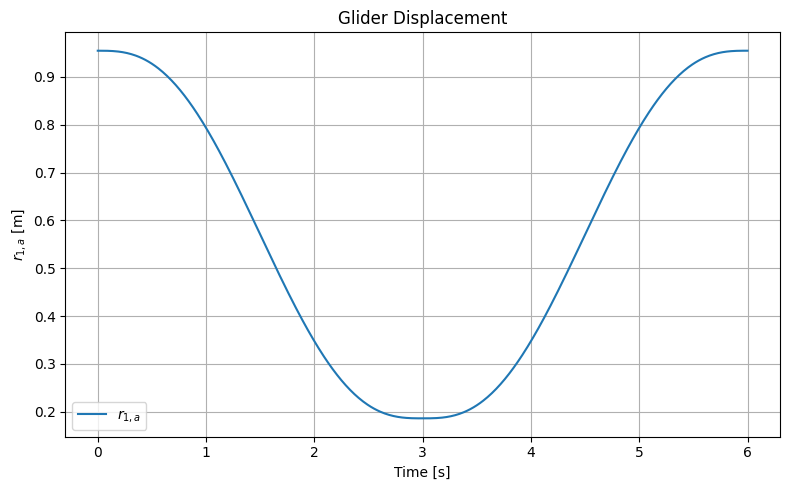

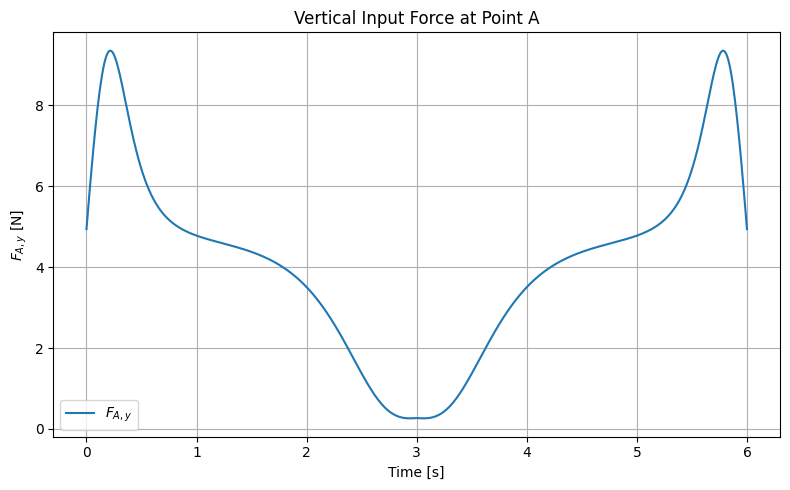

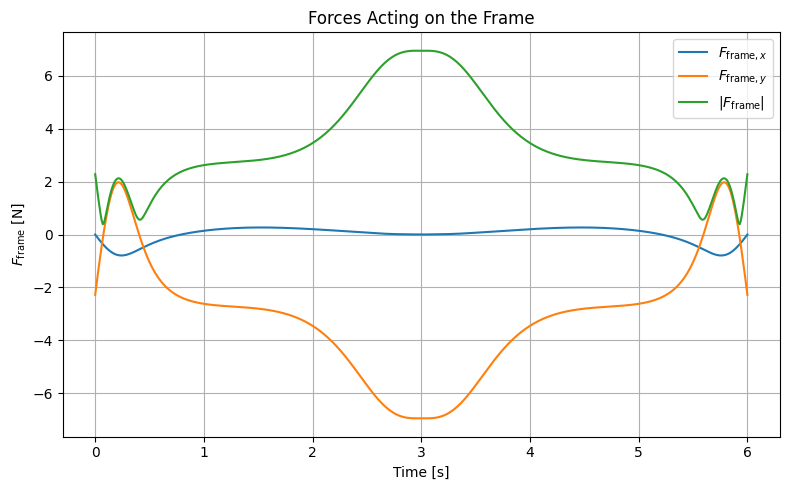

In [13]:

# Use computed forces to plot the total force needed and the total force acting on the frame (without friction)
# Also compute the average force needed during 3s 
F_frame_x = -F_A_x - F_C_x
F_frame_y = -F_C_y
F_frame = np.sqrt(F_frame_x**2 + F_frame_y**2)

total_mass = (
    bar_CH.mass + bar_AE.mass + bar_DG.mass +
    bar_FI.mass + bar_GJ.mass + bar_IK.mass
)
print(f"Total mass = {total_mass:.3f} kg, for 1 rib")
print(f"Total mass = {total_mass*8:.2f} kg, for 8 ribs")

# General plotting style
figsize = (8, 5)

# 1. Glider displacement
plt.figure(figsize=figsize)
plt.plot(t, r1a, label=r'$r_{1,a}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$r_{1,a}$ [m]')
plt.title('Glider Displacement')
plt.grid(True)
plt.legend()
plt.tight_layout()

# 2. Input force at A in y-direction
plt.figure(figsize=figsize)
plt.plot(t, F_A_y, label=r'$F_{A,y}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$F_{A,y}$ [N]')
plt.title('Vertical Input Force at Point A')
plt.grid(True)
plt.legend()
plt.tight_layout()

avg_Fy = np.mean(F_A_y[0:300]) # average force during the first 3 seconds (assuming t is in seconds and timestamps are at 0.01s intervals)
print(f"Average vertical input force at A during 3s: {avg_Fy:.2f} N, for 1 rib")
print(f"Average vertical weight tilt at A during 3s: {avg_Fy*8/g:.2f} kg, for 8 ribs")


# 3. Frame forces
plt.figure(figsize=figsize)
plt.plot(t, F_frame_x, label=r'$F_{\mathrm{frame},x}$')
plt.plot(t, F_frame_y, label=r'$F_{\mathrm{frame},y}$')
plt.plot(t, F_frame, label=r'$|F_{\mathrm{frame}}|$')
plt.xlabel('Time [s]')
plt.ylabel(r'$F_{\mathrm{frame}}$ [N]')
plt.title('Forces Acting on the Frame')
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.show()


<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
Without friction the operator lift weigth for 8 ribs is well below the 4.3 kg documented limit. We can see a difficult crossing point from approx 0.8 s till 1.8 s. There a more constant force between 4 and 5 N per rib is needed for a longer time. We also notice that the force on the frame in x direction is negligible compared to the frame force in y direction. Additionally if the 8 ribs are placed symmetrically the x-forces cancel out anyways. When fully deployed (at 3 s), velocity is zero and only approx 1 N is needed on the glider to keep the umbrella lifted. This tranlsates in a force of approx 6 N on the frame in point C, to keep the mass lifted.

</div>

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h4>Comparison with the kinetic energy method (without friction) </h4>
To make an additional quality assesment of the calculations, we can try to use the change in kinetic energy of the system to also compute the operation force needed. If it can be shown that this method is giving nearly the same value as the previous, then this is a good confirmation of our results.
</div>

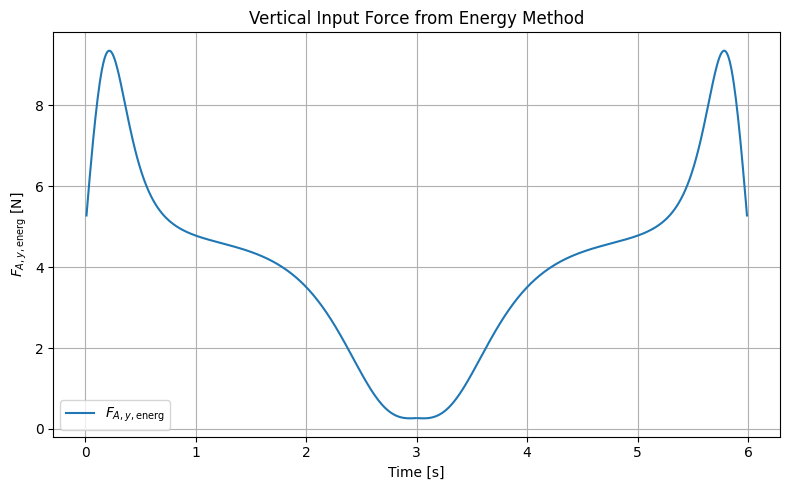

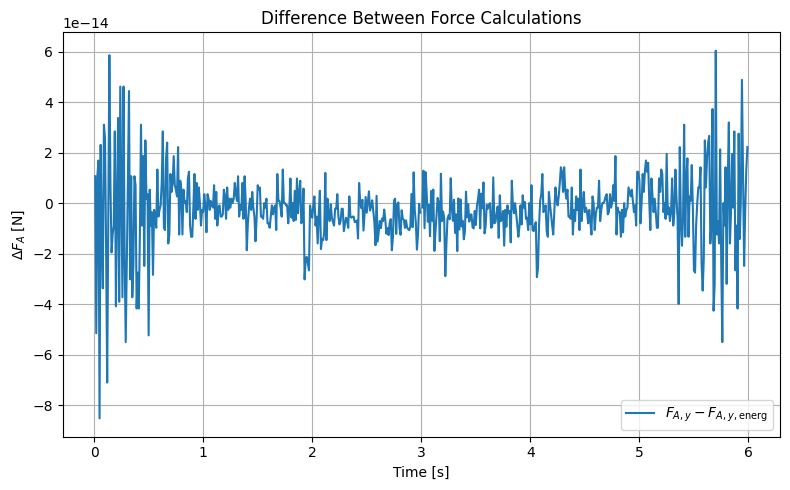

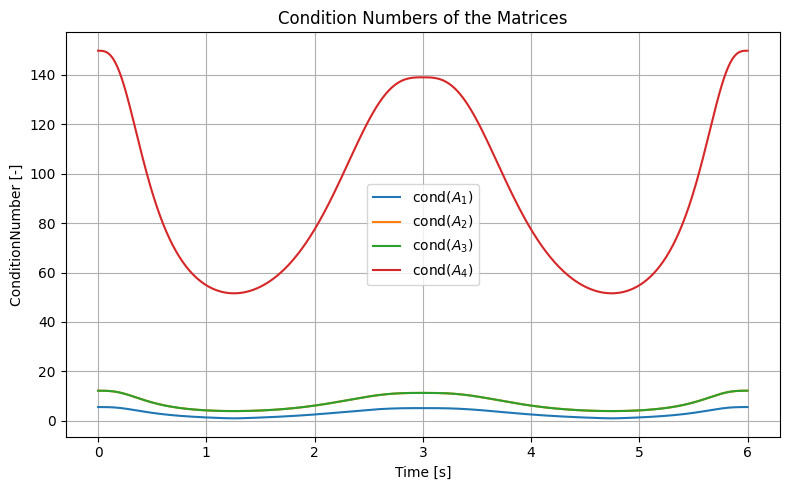

In [14]:
#Compare results with F_A_y via kinetic energy method:
# Calculate the kinetic energy variation in time of all links

all_bars = [bar_CH, bar_AE, bar_DG, bar_FI, bar_GJ, bar_IK]
dEdt = np.zeros_like(t)
for bar in all_bars:
    dEdt += bar.mass * (bar.velocity[0] * bar.acceleration[0] + bar.velocity[1] * bar.acceleration[1]) + bar.inertia * bar.angular_velocity * bar.angular_acceleration + bar.mass * g * bar.velocity[1]
F_A_y_energ = np.zeros_like(t)
for k in range(N):  
    if abs(dr1a[k]) < 1e-6:
        F_A_y_energ[k] = np.nan
    else:
        F_A_y_energ[k] = dEdt[k] / -dr1a[k]

# 1. Input force from energy method
plt.figure(figsize=figsize)
plt.plot(t, F_A_y_energ, label=r'$F_{A,y,\mathrm{energ}}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$F_{A,y,\mathrm{energ}}$ [N]')
plt.title('Vertical Input Force from Energy Method')
plt.grid(True)
plt.legend()
plt.tight_layout()

# 2. Difference between both force calculations
plt.figure(figsize=figsize)
plt.plot(t, F_A_y - F_A_y_energ, label=r'$F_{A,y} - F_{A,y,\mathrm{energ}}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$\Delta F_A$ [N]')
plt.title('Difference Between Force Calculations')
plt.grid(True)
plt.legend()
plt.tight_layout()

# 3. Compare with the condition number of the system matrix to check if the differences are related to numerical issues
plt.figure(figsize=figsize)
plt.plot(t, cond1, label=r'cond$(A_1)$')
plt.plot(t, cond2, label=r'cond$(A_2)$')
plt.plot(t, cond3, label=r'cond$(A_3)$')
plt.plot(t, cond4, label=r'cond$(A_4)$')
plt.xlabel('Time [s]')
plt.ylabel(r'ConditionNumber [-]')
plt.title('Condition Numbers of the Matrices')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
Effectively we see that the difference between both results is in the order of the machine precision. A clear relation between the deviation and the condition number of the solver matrices could not be found.
</div>

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h4>Comparison operator force with and without friction</h4>
As we know the force in x direction that acts on the glider we can also compute the total operator force needed without neglecting friction. Therefore we need a friction coefficient between glider and metal guide. Underneath code makes the assumption of an Iglidur 200J glider with a friction coefficient of approx 0.15. This is also coherent with most literature for friction coefficients between polymer slider and metal guide. Lubrification can reduce this friction coefficient to approx 0.07.
</div>

Average vertical input force at A during 3s with friction: 5.85 N, for 1 rib
Average vertical weight tilt at A during 3s with friction: 4.77 kg, for 8 ribs


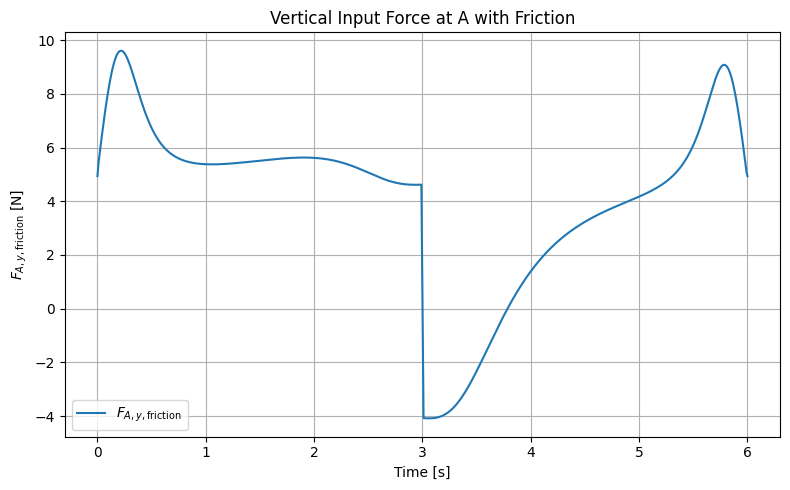

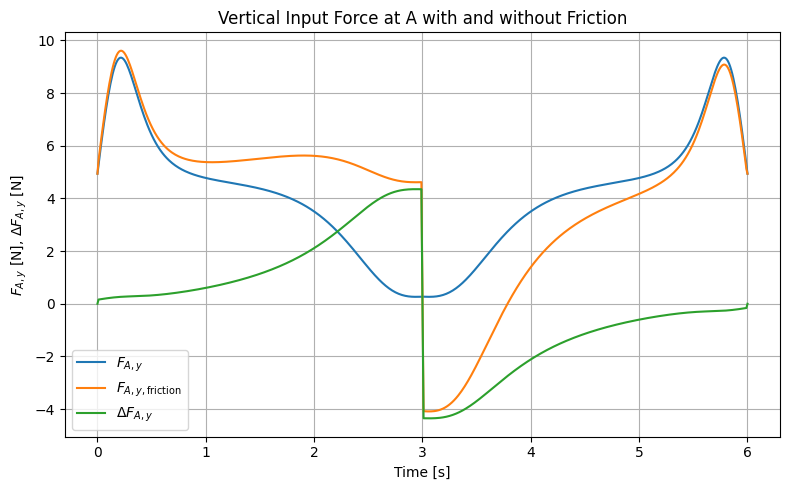

In [15]:
# Compute the average force needed during 3s including friction in the glider
# We introduce a friction coefficient
mu = 0.15 # See slider bearing Iglidur 200J (polymer slider on metal guide)
F_Ay_friction = mu * np.abs(F_A_x) * np.sign(vA[1]) + F_A_y # friction force is proportional to the normal force (F_A_x) and opposes the direction of motion (vA[1])
avg_Fy_friction = np.mean(F_Ay_friction[0:300]) # average force during the first 3 seconds
print(f"Average vertical input force at A during 3s with friction: {avg_Fy_friction:.2f} N, for 1 rib")
print(f"Average vertical weight tilt at A during 3s with friction: {avg_Fy_friction*8/g:.2f} kg, for 8 ribs")

# 1. Plot the force with friction
plt.figure(figsize=figsize)
plt.plot(t, F_Ay_friction, label=r'$F_{A,y,\mathrm{friction}}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$F_{A,y,\mathrm{friction}}$ [N]')
plt.title('Vertical Input Force at A with Friction')

plt.grid(True)
plt.legend()
plt.tight_layout()
# 2. Compare the force with friction to the force without friction
plt.figure(figsize=figsize)
plt.plot(t, F_A_y, label=r'$F_{A,y}$')
plt.plot(t, F_Ay_friction, label=r'$F_{A,y,\mathrm{friction}}$')
plt.plot(t, F_Ay_friction - F_A_y, label=r'$\Delta F_{A,y}$')
plt.xlabel('Time [s]')
plt.ylabel(r'$F_{A,y}$ [N], $\Delta F_{A,y}$ [N]')
plt.title('Vertical Input Force at A with and without Friction')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
With friction coefficient 0.15 the vertical (overhead) weigth tilt for 8 ribs is more than the documented limit of 4.3 kg. Due to the friction the difficult point that had to be crossed is more emphasized and requires more force to be crossed. When vertical velocity hits 0 at the end of the movement (at 3 s), the additional fricion force becomes zero too and the total operator force goes to the value without friction. Because of the friction working in oposite direction than de vertical glider velocity the operator force is assymetric, it needs different forces to glide up than gliding down. Lubrification or beter bearings will have to be used if we want overhead tilt to be underneath 4.3 kg. It corresponds to a friction factor underneath 0.1. 
</div>

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h4>Power need and consumed energy</h4>
Based on the operator force and glider velocity the input power and consumed energy can be computed. We can translate that in a kcal value for the muscle using the metabolic efficiency of the human. Underneath code is plotting/showing these values.
</div>

Average power at A during 3s: 1.07 W, for 1 rib
Average power at A during 3s with friction: 1.43 W, for 1 rib
Average power at A during 3s: 8.56 W, for 8 ribs
Average power at A during 3s with friction: 11.46 W, for 8 ribs


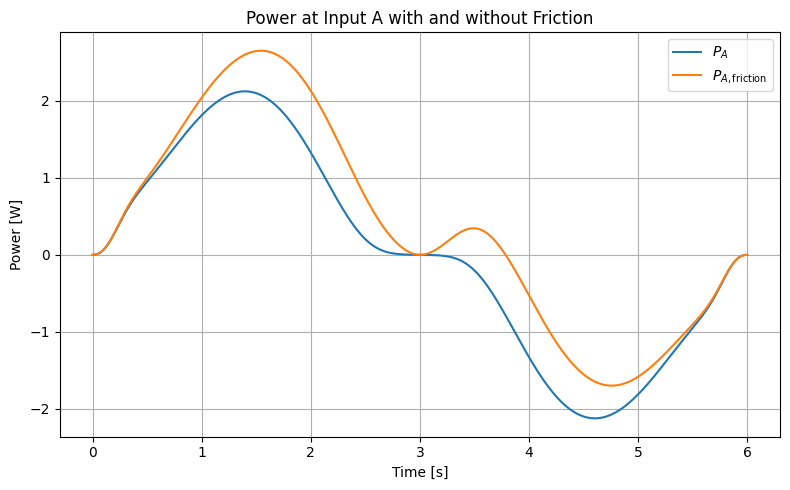

Total muscle energy for upward movement at A: 0.004 kcal, for 1 rib
Total muscle energy for upward movement at A: 0.03 kcal, for 8 ribs


: 

In [ ]:
# Calculate the power needed at the input A, with and without friction
Power_A = F_A_y * vA[1]
Power_A_friction = F_Ay_friction * vA[1]
# 1. Plot the power at A
plt.figure(figsize=figsize)
plt.plot(t, Power_A, label=r'$P_{A}$')
plt.plot(t, Power_A_friction, label=r'$P_{A,\mathrm{friction}}$')
plt.xlabel('Time [s]')
plt.ylabel(r'Power [W]')
plt.title('Power at Input A with and without Friction')
plt.grid(True)
plt.legend()
plt.tight_layout()
# 2. Compute the average power needed during 3s
avg_Power_A = np.mean(Power_A[0:300])
avg_Power_A_friction = np.mean(Power_A_friction[0:300])
print(f"Average power at A during 3s: {avg_Power_A:.2f} W, for 1 rib")
print(f"Average power at A during 3s with friction: {avg_Power_A_friction:.2f} W, for 1 rib")
print(f"Average power at A during 3s: {avg_Power_A*8:.2f} W, for 8 ribs")
print(f"Average power at A during 3s with friction: {avg_Power_A_friction*8:.2f} W, for 8 ribs")
plt.show()

# 3. Compute the total energy for upward movement with friction and convert in kcal
meta_eff = 0.25 # efficiency of the human muscle (see https://en.wikipedia.org/wiki/Human_efficiency)
Energy_A = avg_Power_A_friction * 3 # integrate power over time to get energy or simply multiply average power by time duration (3s)
Energy_A_kcal = Energy_A / (4184 * meta_eff)  # convert J to kcal for muscle energy considering the efficiency
print(f"Total muscle energy for upward movement at A: {Energy_A_kcal:.3f} kcal, for 1 rib")
print(f"Total muscle energy for upward movement at A: {Energy_A_kcal*8:.2f} kcal, for 8 ribs")


<div style="max-width: 700px; margin: 0 auto; text-align: justify;">
A muscle burn of 0.03 kcal and average power to deliver of approx 11 W in 3 s is not much globally. The limitting factor is lying in the peak force that the muscle has to deliver in certain positions. For overhead push a minimal documented limit is 4.3 kg of weigth for 4s. We have shown previously that the average operator force for a 3 second deployment of this mechanism (with these configurations), can stay underneath this value. At least if the friction is not too high (good lubrification).
</div>